In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

from support_sense.data_split import split_dataset
from support_sense.evaluation import (
    get_top_features_by_class,
)
from support_sense.metrics import calculate_classification_metrics
from support_sense.modeling import build_text_pipeline, create_classifier

In [2]:
# Locate the unchanged raw dataset.
DATA_PATH = Path("../data/support_tickets.csv")

In [3]:
# Load all labeled tickets.
df = pd.read_csv(DATA_PATH)

# Define the priority training data

In [4]:
train_df, validation_df, test_df = split_dataset(
    df,
    target_column="priority",
)

In [5]:
X_train = train_df["text"]
y_train = train_df["priority"]

X_validation = validation_df["text"]
y_validation = validation_df["priority"]

# Train the second classifier

In [6]:
priority_model = build_text_pipeline(
    create_classifier("logistic_regression"), ngram_range=(1, 1)
)

In [7]:
priority_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['high','low','medium']"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True


# Generate validation predictions

In [8]:
priority_predictions = priority_model.predict(X_validation)

In [9]:
set(priority_predictions)

{'high', 'low', 'medium'}

# Calculate the usual metrics

In [10]:
priority_metrics = calculate_classification_metrics(y_validation, priority_predictions)

priority_metrics

{'accuracy': 0.37777777777777777,
 'precision_macro': 0.33730158730158727,
 'recall_macro': 0.3162037037037037,
 'f1_macro': 0.30277777777777776}

# Generate the priority classification report

In [11]:
priority_report = classification_report(
    y_validation,
    priority_predictions,
    labels=["low", "medium", "high"],
    output_dict=True,
    zero_division=0,
)

In [12]:
priority_report_df = pd.DataFrame(priority_report).transpose()

priority_report_df

,precision,recall,f1-score,support
low,0.333333,0.111111,0.166667,9.000000
medium,0.464286,0.650000,0.541667,20.000000
high,0.214286,0.187500,0.200000,16.000000
accuracy,0.377778,0.377778,0.377778,0.377778
macro avg,0.337302,0.316204,0.302778,45.000000
weighted avg,0.349206,0.377778,0.345185,45.000000


# Build the priority confusion matrix

In [13]:
PRIORITY_LABELS = [
    "low",
    "medium",
    "high",
]

In [14]:
priority_confusion = confusion_matrix(
    y_validation, priority_predictions, labels=PRIORITY_LABELS
)

In [15]:
# row    = medium
# column = high
# means
# actual medium
# predicted high

priority_confusion_df = pd.DataFrame(
    priority_confusion, index=PRIORITY_LABELS, columns=PRIORITY_LABELS
)

priority_confusion_df

,low,medium,high
low,1,3,5
medium,1,13,6
high,1,12,3


# Visualize it

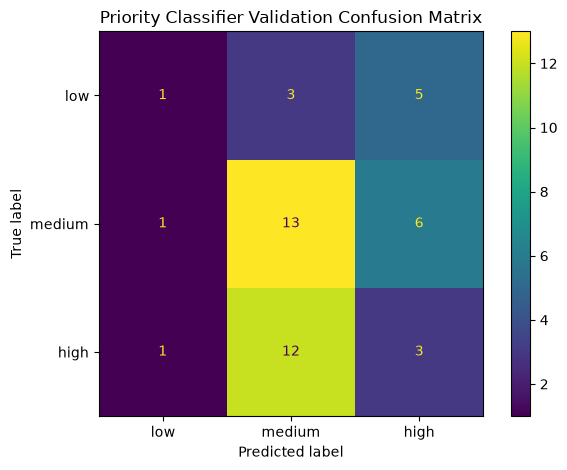

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    priority_predictions,
    labels=PRIORITY_LABELS,
)

plt.title("Priority Classifier Validation Confusion Matrix")
plt.tight_layout()
plt.show()

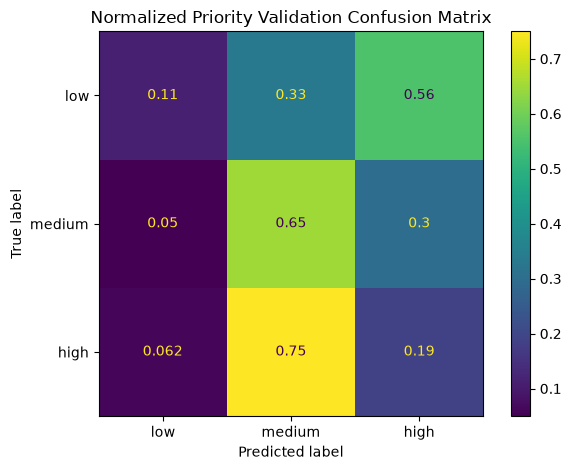

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_validation, priority_predictions, labels=PRIORITY_LABELS, normalize="true"
)

plt.title("Normalized Priority Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# Explicitly measure the important confusion pairs

In [18]:
medium_as_high = priority_confusion_df.loc[
    "medium",
    "high",
]

high_as_medium = priority_confusion_df.loc[
    "high",
    "medium",
]

low_as_medium = priority_confusion_df.loc[
    "low",
    "medium",
]

medium_as_low = priority_confusion_df.loc[
    "medium",
    "low",
]

In [19]:
print(
    "medium → high:",
    medium_as_high,
)

print(
    "high → medium:",
    high_as_medium,
)

print(
    "low → medium:",
    low_as_medium,
)

print(
    "medium → low:",
    medium_as_low,
)

medium → high: 6
high → medium: 12
low → medium: 3
medium → low: 1


# Build priority error analysis

In [20]:
priority_probabilities = priority_model.predict_proba(X_validation)

In [21]:
priority_confidence = priority_probabilities.max(axis=1)

In [22]:
priority_analysis_df = validation_df[
    [
        "ticket_id",
        "text",
        "priority",
    ]
].copy()

In [23]:
priority_analysis_df = priority_analysis_df.rename(
    columns={"priority": "actual_priority"}
)

In [24]:
priority_analysis_df["predicted_priority"] = priority_predictions

priority_analysis_df["confidence"] = priority_confidence

In [25]:
priority_analysis_df["is_correct"] = (
    priority_analysis_df["actual_priority"]
    == priority_analysis_df["predicted_priority"]
)

priority_analysis_df.head()

,ticket_id,text,actual_priority,predicted_priority,confidence,is_correct
0,TKT-1239,"Hey team, I cancelled but I was still charged....",high,medium,0.696851,False
1,TKT-1211,"Hi there, The refund amount is lower than expe...",high,high,0.397669,True
2,TKT-1171,"Hey team, My delivery is delayed again. This i...",high,medium,0.515708,False
3,TKT-1297,"Hey team, Can I use the service on multiple de...",medium,medium,0.551490,True
4,TKT-1181,"Hi there, Can I change the shipping address be...",low,high,0.369562,False


# Extract mistakes

In [26]:
priority_errors_df = priority_analysis_df[~priority_analysis_df["is_correct"]].copy()

In [27]:
priority_errors_df = priority_errors_df.sort_values("confidence", ascending=False)

priority_errors_df.head()

,ticket_id,text,actual_priority,predicted_priority,confidence,is_correct
23,TKT-1053,"Hey team, Two factor authentication is not sen...",high,medium,0.728498,False
17,TKT-1201,"Hi, I need to stop my renewal. This happened a...",medium,high,0.703173,False
0,TKT-1239,"Hey team, I cancelled but I was still charged....",high,medium,0.696851,False
41,TKT-1252,"Hey team, What payment methods do you accept. ...",low,medium,0.682796,False
5,TKT-1121,"Hey team, The mobile app freezes on the checko...",high,medium,0.650157,False


# Create the priority error report

In [28]:
priority_errors_df[
    ["ticket_id", "text", "actual_priority", "predicted_priority", "confidence"]
].to_csv(
    "../reports/priority_error_analysis.csv",
    index=False,
)

# Filter specifically for medium ↔ high

In [29]:
medium_high_errors = priority_errors_df[
    (
        (priority_errors_df["actual_priority"] == "medium")
        & (priority_errors_df["predicted_priority"] == "high")
    )
    | (
        (priority_errors_df["actual_priority"] == "high")
        & (priority_errors_df["predicted_priority"] == "medium")
    )
]

In [30]:
medium_high_errors[
    [
        "text",
        "actual_priority",
        "predicted_priority",
        "confidence",
    ]
]

,text,actual_priority,predicted_priority,confidence
23,"Hey team, Two factor authentication is not sen...",high,medium,0.728498
17,"Hi, I need to stop my renewal. This happened a...",medium,high,0.703173
0,"Hey team, I cancelled but I was still charged....",high,medium,0.696851
5,"Hey team, The mobile app freezes on the checko...",high,medium,0.650157
30,"Hi there, My account was disabled unexpectedly...",high,medium,0.636955
37,"Hello support, Search results are not appearin...",high,medium,0.612231
29,"Hey team, Notifications stopped working after ...",high,medium,0.553779
34,I get an error when trying to save changes. I ...,high,medium,0.546225
2,"Hey team, My delivery is delayed again. This i...",high,medium,0.515708
36,"Hi there, The page refreshes every time I clic...",high,medium,0.502417


# Inspect low ↔ medium separately

In [31]:
low_medium_errors = priority_errors_df[
    (
        (priority_errors_df["actual_priority"] == "low")
        & (priority_errors_df["predicted_priority"] == "medium")
    )
    | (
        (priority_errors_df["actual_priority"] == "medium")
        & (priority_errors_df["predicted_priority"] == "low")
    )
]

In [32]:
low_medium_errors[
    [
        "text",
        "actual_priority",
        "predicted_priority",
        "confidence",
    ]
]

,text,actual_priority,predicted_priority,confidence
41,"Hey team, What payment methods do you accept. ...",low,medium,0.682796
26,"Hey team, The box arrived damaged. Please help.",low,medium,0.483153
6,"Good day, How long does a refund take. This is...",low,medium,0.432112
32,"Hello support, The courier marked the package ...",medium,low,0.360133


# Inspect feature coefficients

In [33]:
priority_features = get_top_features_by_class(
    priority_model,
    top_n=15,
)

for category, features in priority_features.items():
    print(f"\n{category}")

    for term, coefficient in features:
        print(f"{term:20} {coefficient:.4f}")


high
after                0.6723
very                 0.4995
loading              0.4995
slowly               0.4995
dashboard            0.4995
my                   0.4703
good                 0.4210
update               0.4031
cannot               0.3986
will                 0.3543
be                   0.3543
page                 0.3340
applied              0.3240
was                  0.3189
day                  0.3151

low
does                 0.7227
you                  0.7103
billing              0.6515
option               0.6515
annual               0.6515
offline              0.6359
mode                 0.5368
app                  0.4874
how                  0.4697
order                0.4624
country              0.4615
product              0.4615
available            0.4615
arrived              0.4594
than                 0.4275

medium
help                 0.4527
two                  0.4314
factor               0.4314
sending              0.4314
authentication       0.4314
o